# Exercises - Estimating the Spot Curve

#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$

### Data

This exercise uses the data file, `treasury_quotes_2025-11-28`.

The problems below analyze the nominal, (rather than the TIPS,) Treasury issues. Accordingly, you should filter out all rows with `type` `TIPS Note` or `TIPS bond`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
SHEET_NAME = 'treasury_quotes_2025-11-28.xlsx'
df = pd.read_excel(SHEET_NAME, sheet_name='quotes')
nominal_df = df[df["type"].isin(["bill", "note"])].copy()
nominal_df.head()

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,duration
0,208422,bill,2025-11-28,2025-08-05,2025-12-02,0.010951,NaN,0.0,99.989146,99.989174,99.989160,0.000000,99.989160,0.009924,2.657700e+11,0.010959
1,208397,bill,2025-11-28,2025-06-05,2025-12-04,0.016427,NaN,0.0,99.967491,99.967574,99.967532,0.000000,99.967532,0.019866,2.514150e+11,0.016438
2,208432,bill,2025-11-28,2025-08-12,2025-12-09,0.030116,NaN,0.0,99.913089,99.913311,99.913200,0.000000,99.913200,0.029043,2.707090e+11,0.030137
3,208410,bill,2025-11-28,2025-06-12,2025-12-11,0.035592,NaN,0.0,99.891417,99.891694,99.891556,0.000000,99.891556,0.030719,2.552590e+11,0.035616
4,207988,note,2025-11-28,2022-12-15,2025-12-15,0.046543,0.907104,4.0,99.998315,99.998711,99.998513,1.814208,101.812721,0.039877,3.999900e+10,0.046575


# 1. Discount Rates

Use the data in the `selected quotes` tab.

Note:
* The selected treasuries are at nearly six-month intervals. 
* If you prefer, approximate that they mature at perfect 6-month intervals. 

In [2]:
selected_quotes = pd.read_excel(SHEET_NAME, sheet_name='selected quotes')

### 1.1.

Create the cashflow matrix, $\textbf{C}$, where each rows is a Treasury issue, each column is a date, and each entry is the cash paid on a (normalized) face value of \$100.

In [3]:
selected_quotes["maturity date"] = pd.to_datetime(selected_quotes["maturity date"])
selected_quotes = selected_quotes.sort_values("maturity date").reset_index(drop=True)

n = len(selected_quotes)

# semiannual coupon cashflow on $100 face
c_semi = (selected_quotes["cpn rate"].to_numpy() / 100.0) * 100.0 / 2.0  # = cpn rate / 2

L = np.tril(np.ones((n, n)))            # lower-triangular ones
C = c_semi[:, None] * L + 100.0 * np.eye(n)

# nice labeled DataFrame (optional but recommended)
C_df = pd.DataFrame(
    C,
    index=selected_quotes["KYTREASNO"],
    columns=selected_quotes["maturity date"]  # 6-mo grid dates
)

C_df


maturity date,2026-05-31,2026-11-30,2027-05-31,2027-11-30,2028-05-31,2028-11-30,2029-05-31,2029-11-30,2030-05-31,2030-11-30,2031-05-31,2031-11-30,2032-05-31,2032-11-30,2033-05-15,2033-11-15,2034-05-15,2034-11-15,2035-05-15,2035-11-15
KYTREASNO,,,,,,,,,,,,,,,,,,,,
208227,102.4375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208316,2.1250,102.1250,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208399,1.9375,1.9375,101.9375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208484,1.6875,1.6875,1.6875,101.6875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208058,1.8125,1.8125,1.8125,1.8125,101.8125,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208145,2.1875,2.1875,2.1875,2.1875,2.1875,102.1875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208229,2.2500,2.2500,2.2500,2.2500,2.2500,2.2500,102.2500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208318,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,102.0625,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208401,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,102.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0


### 1.2.

Estimate the spot discount factors that rationalize the market prices of the treasuries. Do this via solving the linear system

$$\textbf{p} = {\textbf{C}}\, \textbf{z}$$

In [4]:
from scipy import linalg

C = np.array(C_df)
p = np.array(selected_quotes[['price']])

z = linalg.solve(C, p)
display(z)

array([[0.9813429 ],
       [0.96447159],
       [0.94855058],
       [0.93308752],
       [0.91722537],
       [0.90105047],
       [0.88495417],
       [0.86844763],
       [0.85254463],
       [0.83646536],
       [0.81864008],
       [0.80186849],
       [0.7846308 ],
       [0.76799179],
       [0.75085014],
       [0.73504424],
       [0.71814171],
       [0.70092077],
       [0.68434715],
       [0.66844766]])

### 1.3.

Plot the time-to-maturity on the horizontal axis. On the vertical axis, plot the...
* discount factors

Make another plot, this time with the vertical axis displaying the
* semiannually compounded discount rates
* continuously compounded discount rates

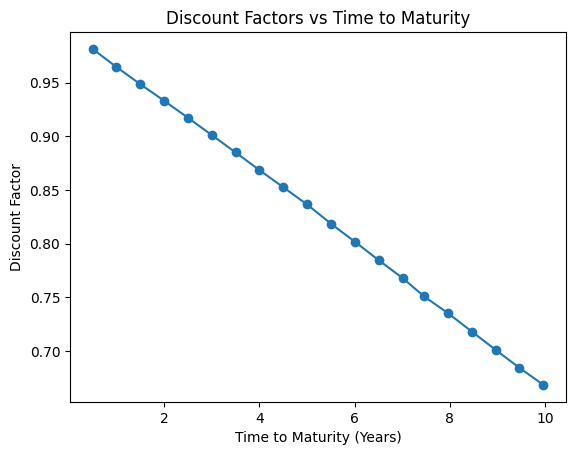

In [5]:
#Discount Factors vs TTM:
ttm = selected_quotes['ttm'].to_numpy(dtype=float)
z_arr = z

plt.figure()
plt.plot(ttm, z_arr, marker='o')
plt.title('Discount Factors vs Time to Maturity')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Discount Factor')
plt.show()


In [6]:
def discount_to_spot_freq(z, ttm, freq=2):
    """
    Convert discount factors z(T) to spot rates.

    z can be shape (n,) or (n,1). Returns shape (n,).
    """
    z = np.asarray(z, dtype=float).reshape(-1)      # force 1-D
    ttm = np.asarray(ttm, dtype=float).reshape(-1)  # force 1-D

    if z.shape != ttm.shape:
        raise ValueError(f"Shape mismatch: z{z.shape} vs ttm{ttm.shape}")

    r = np.full_like(z, np.nan, dtype=float)
    valid = (z > 0) & np.isfinite(z) & (ttm > 0) & np.isfinite(ttm)

    if freq is None:
        # continuous compounding: z = exp(-rT)
        r[valid] = -np.log(z[valid]) / ttm[valid]
    else:
        f = float(freq)
        # discrete compounding: z = (1 + r/f)^(-fT)
        r[valid] = f * (np.power(z[valid], -1.0 / (f * ttm[valid])) - 1.0)

    return r

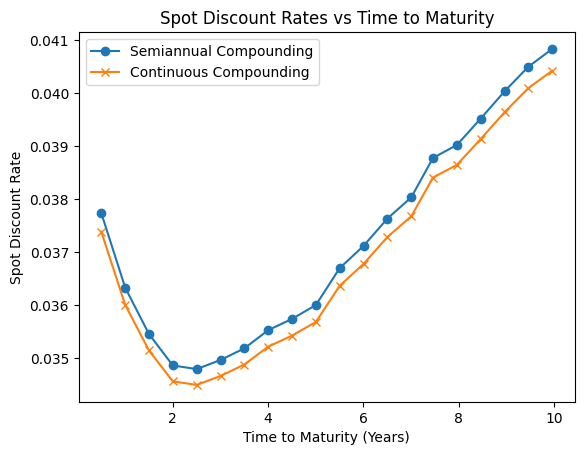

In [7]:
ttm = selected_quotes['ttm'].to_numpy(dtype=float)
z_arr = np.asarray(z, dtype=float).reshape(-1)

r_sa = discount_to_spot_freq(z_arr, ttm=ttm, freq=2)
r_cc = discount_to_spot_freq(z_arr, ttm=ttm, freq=None)

plt.figure()
plt.plot(ttm, r_sa, marker='o', label='Semiannual Compounding')
plt.plot(ttm, r_cc, marker='x', label='Continuous Compounding')
plt.title('Spot Discount Rates vs Time to Maturity')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Spot Discount Rate')
plt.legend()
plt.show()

### 1.4. Curve-Fitting

Estimate the discount curve via the Nelson-Siegel model.
* Fit via minimizing the sum of squared errors of the modeled prices against the quoted prices.
* Consider using `minimize` from `scipy.optimize`.

When done,
* Report the estimated NS parameters.
* Plot the semiannually-compounded discount rates along with those estimated with OLS from above.

In [8]:
#Implement NS Model
from scipy.optimize import minimize

t = 0.5 * np.arange(1, C.shape[1] + 1)  # semiannual time grid
p_mkt = selected_quotes['dirty price'].to_numpy(dtype=float)

def ns_yield_count(t, beta0, beta1, beta2, tau):
    "Nelson-Siegel continuously compounded spot rate y(t)"
    t = np.asarray(t, dtype=float)
    x = t / tau

    f1 = np.where(t == 0, 1.0, (1.0 - np.exp(-x)) / x)
    f2 = f1 - np.exp(-x)

    return beta0 + beta1 * f1 + beta2 * f2

def ns_discount(t, beta0, beta1, beta2, tau):
    "Nelson-Siegel discount factor z(t) using continously compounded yield"
    r = ns_yield_count(t, beta0, beta1, beta2, tau)
    return np.exp(-r * t)

def price_from_discount(C, z):
    "Model prices from cashflow matrix C and discount factors z, p = Cz"
    return C @ z

def ns_objecive(params, C, p_mkt, t):
    "Objective function to minimize: sum of squared price errors"
    beta0, beta1, beta2, tau = params

    if tau <=0:
        return 1e12

    z_hat = ns_discount(t, beta0, beta1, beta2, tau)
    p_hat = C @ z_hat
    error = p_hat - p_mkt
    return np.sum(error ** 2)

In [9]:
#Implement Nelson-Siegel model
z_ols = np.linalg.solve(C, p_mkt)
y0 = -np.log(z_ols) / t  # initial guess for spot rates
beta0_init = float(np.mean(y0[-5:]))  # average of longest 5 maturities
beta1_init = float(y0[0] - beta0_init)   # difference between shortest and long avg
beta2_init = 0.0                         # initial curvature
tau_init = 2.0                           # initial decay parameter
x0 = np.array([beta0_init, beta1_init, beta2_init, tau_init], dtype=float)
res = minimize(
    ns_objecive,
    x0,
    args=(C, p_mkt, t),
    method='L-BFGS-B'
)

beta0_hat, beta1_hat, beta2_hat, tau_hat = res.x

results_tbl = pd.DataFrame(
    {
        "theta 0":   [beta0_hat],
        "theta 1":   [beta1_hat],
        "theta 2":   [beta2_hat],
        "lambda_1":  [tau_hat],
        "theta_3":   [None],
        "lambda_2":  [None],
    },
    index=["Nelson-Siegel"]
)

display(results_tbl)

,theta 0,theta 1,theta 2,lambda_1,theta_3,lambda_2
Nelson-Siegel,0.057308,-0.039594,-0.000087,4.651173,None,None


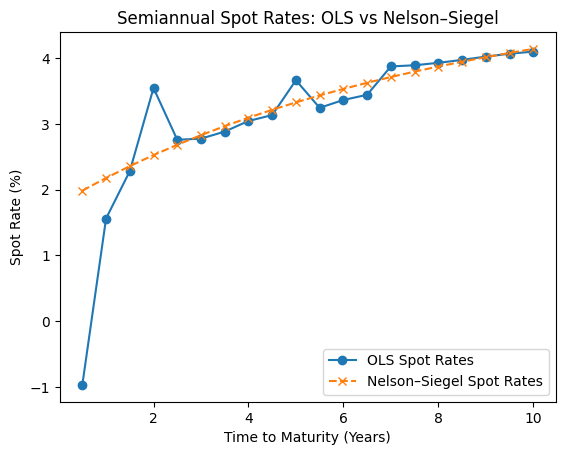

In [26]:
# --- NS approach ---
z_ns = ns_discount(t, beta0_hat, beta1_hat, beta2_hat, tau_hat)
r_ns_sa = discount_to_spot_freq(z_ns, ttm=t, freq=2)

# --- OLS approach ---
C_mat = C_df.to_numpy(dtype=float)
p_mkt = (
    selected_quotes
      .set_index("KYTREASNO")["dirty price"]
      .loc[C_df.index]
      .to_numpy(dtype=float)
)

res = sm.OLS(p_mkt, C_mat).fit()  # no constant
z_ols = res.params
r_ols_sa = discount_to_spot_freq(z_ols, ttm=t, freq=2)

# --- Plot ---
plt.figure()
plt.plot(t, 100 * r_ols_sa, marker='o', linestyle='-', label='OLS Spot Rates')
plt.plot(t, 100 * r_ns_sa, marker='x', linestyle='--', label='Nelson–Siegel Spot Rates')
plt.title('Semiannual Spot Rates: OLS vs Nelson–Siegel')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Spot Rate (%)')
plt.legend()
plt.show()


***

# 2. Estimating the Discount Curve with Non-Evenly Spaced Data

Use the data in the `quotes` tab.

In [28]:
quotes_data = pd.read_excel(SHEET_NAME, sheet_name='quotes')
nominal_df = quotes_data[quotes_data["type"].isin(["bill", "note"])].copy()

### 2.1. Map Cashflows

Construct the cashflow matrix.

Given the unfiltered data set, you will need to make a few modeling choices to do this...
* eliminate any treasury that does not report YTM or that reports a negative YTM.
* assume notes and bonds pay coupons every six months, going backward from the date of maturity.

Make other reasonable modeling assumptions as needed.

Report:
* head and tail rows of the dataframe, $\textbf{C}$, for instance, using `display()`.

* which date has the most cashflow across all issues?

* which date has the most issues paying a cashflow?

In [29]:
#to keep things smooth assume 1x per month

nominal_df['quote date'] = pd.to_datetime(nominal_df['quote date'])
nominal_df['maturity date'] = pd.to_datetime(nominal_df['maturity date'])

#eliminate missing and negative/zero YTM
nominal_df = nominal_df[nominal_df["ytm"].notna() & (nominal_df["ytm"] > 0)].copy()

#curve date
quote_date = (nominal_df["quote date"].iloc[0])
nominal_df['mat_snap'] = nominal_df['maturity date'] + pd.offsets.MonthEnd(0)

def coupon_schedule(maturity_date):
    dts = pd.date_range( end=maturity_date, freq='-6MS', periods = 1000) #backward grid
    dts = dts[dts > quote_date]
    return dts

schedules = {}
all_dates = pd.DatetimeIndex([])

for _, row in nominal_df.iterrows():
    k = row["KYTREASNO"]
    mat = row["mat_snap"]
    typ = row["type"]

    if typ == "bill":
        sched = pd.DatetimeIndex([mat]) if mat > quote_date else pd.DatetimeIndex([])

    else:
        sched = []
        d = mat
        while d > quote_date:
            sched.append(d + pd.offsets.MonthEnd(0))
            d -= pd.DateOffset(months=6)

        sched = pd.DatetimeIndex(pd.unique(sched)).sort_values()

    schedules[k] = sched
    all_dates = all_dates.union(sched)

all_dates = all_dates.sort_values()


FACE = 100.0
C = pd.DataFrame(0.0, index=nominal_df["KYTREASNO"], columns=all_dates)

for _, row in nominal_df.iterrows():
    k = row["KYTREASNO"]
    sched = schedules[k]

    if len(sched) == 0:
        continue

    if row["type"] == "bill":
        C.loc[k, sched[-1]] = FACE

    else:
        c_semi = FACE * (row["cpn rate"] / 100.0) / 2.0
        C.loc[k, sched] = c_semi
        C.loc[k, sched[-1]] += FACE

display(C.head())
display(C.tail())


/var/folders/1_/gb2cs27x3nq4pp7f6whksw7h0000gn/T/ipykernel_6648/696612801.py:36: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  sched = pd.DatetimeIndex(pd.unique(sched)).sort_values()
/var/folders/1_/gb2cs27x3nq4pp7f6whksw7h0000gn/T/ipykernel_6648/696612801.py:36: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  sched = pd.DatetimeIndex(pd.unique(sched)).sort_values()
/var/folders/1_/gb2cs27x3nq4pp7f6whksw7h0000gn/T/ipykernel_6648/696612801.py:36: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  sched = pd.DatetimeIndex(pd.unique(sched)).sort_values()
/var/folders/1_/gb2cs27x3nq4pp7f6whksw7h0000gn/T/ipykernel_6648/696612801.py:36: FutureWarning: unique with argument that is not not 

,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31,2026-08-31,...,2033-08-31,2033-11-30,2034-02-28,2034-05-31,2034-08-31,2034-11-30,2035-02-28,2035-05-31,2035-08-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,,
208422,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208397,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208432,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208410,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
207988,0.0,102.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31,2026-08-31,...,2033-08-31,2033-11-30,2034-02-28,2034-05-31,2034-08-31,2034-11-30,2035-02-28,2035-05-31,2035-08-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,,
208320,2.125,0.0,0.0,0.0000,0.0,0.0,2.125,0.0,0.0,0.0000,...,0.0000,2.125,0.0000,2.125,0.0000,102.125,0.0000,0.000,0.000,0.0
208360,0.000,0.0,0.0,2.3125,0.0,0.0,0.000,0.0,0.0,2.3125,...,2.3125,0.000,2.3125,0.000,2.3125,0.000,102.3125,0.000,0.000,0.0
208403,2.125,0.0,0.0,0.0000,0.0,0.0,2.125,0.0,0.0,0.0000,...,0.0000,2.125,0.0000,2.125,0.0000,2.125,0.0000,102.125,0.000,0.0
208446,0.000,0.0,0.0,2.1250,0.0,0.0,0.000,0.0,0.0,2.1250,...,2.1250,0.000,2.1250,0.000,2.1250,0.000,2.1250,0.000,102.125,0.0
208488,2.000,0.0,0.0,0.0000,0.0,0.0,2.000,0.0,0.0,0.0000,...,0.0000,2.000,0.0000,2.000,0.0000,2.000,0.0000,2.000,0.000,102.0


In [31]:
#Most Cashflow:
total_cashflow_by_date = C.sum(axis=0)
max_cf_date = total_cashflow_by_date.idxmax()
max_cf_value = total_cashflow_by_date.max()

print("Date with most total cashflow:", max_cf_date)
print("Total cashflow on that date:", max_cf_value)


#Most Issues Paying:
issues_paying_by_date = (C > 0).sum(axis=0)
max_issues_date = issues_paying_by_date.idxmax()
max_issues_count = issues_paying_by_date.max()

print("Date with most issues paying:", max_issues_date)
print("Number of issues paying:", max_issues_count)

Date with most total cashflow: 2026-02-28 00:00:00
Total cashflow on that date: 1377.0
Date with most issues paying: 2026-02-28 00:00:00
Number of issues paying: 61


### 2.2. OLS

Estimate the discount factors using OLS.

Starting with the cashflow matrix, $C$, create an additional filter to get a subset where every date has at least one maturity, (possibly multiple,) and every issue has its maturity in the cashflow matrix. Call this set of cashflows, $\hat{C}$.

**Report 5 head and tail rows of $\hat{C}$.**

$$\textbf{p} = \hat{\textbf{C}}\,\textbf{z}_{\text{ols}}+\epsilon$$

Plot the time-to-maturity vs discount rates, semiannually compounded.

,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31,2026-08-31,2026-09-30,...,2033-08-31,2033-11-30,2034-02-28,2034-05-31,2034-08-31,2034-11-30,2035-02-28,2035-05-31,2035-08-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,,
208422,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208397,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208432,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208410,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
207988,102.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31,2026-08-31,2026-09-30,...,2033-08-31,2033-11-30,2034-02-28,2034-05-31,2034-08-31,2034-11-30,2035-02-28,2035-05-31,2035-08-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,,
208320,0.0,0.0,0.0000,0.0,0.0,2.125,0.0,0.0,0.0000,0.0,...,0.0000,2.125,0.0000,2.125,0.0000,102.125,0.0000,0.000,0.000,0.0
208360,0.0,0.0,2.3125,0.0,0.0,0.000,0.0,0.0,2.3125,0.0,...,2.3125,0.000,2.3125,0.000,2.3125,0.000,102.3125,0.000,0.000,0.0
208403,0.0,0.0,0.0000,0.0,0.0,2.125,0.0,0.0,0.0000,0.0,...,0.0000,2.125,0.0000,2.125,0.0000,2.125,0.0000,102.125,0.000,0.0
208446,0.0,0.0,2.1250,0.0,0.0,0.000,0.0,0.0,2.1250,0.0,...,2.1250,0.000,2.1250,0.000,2.1250,0.000,2.1250,0.000,102.125,0.0
208488,0.0,0.0,0.0000,0.0,0.0,2.000,0.0,0.0,0.0000,0.0,...,0.0000,2.000,0.0000,2.000,0.0000,2.000,0.0000,2.000,0.000,102.0


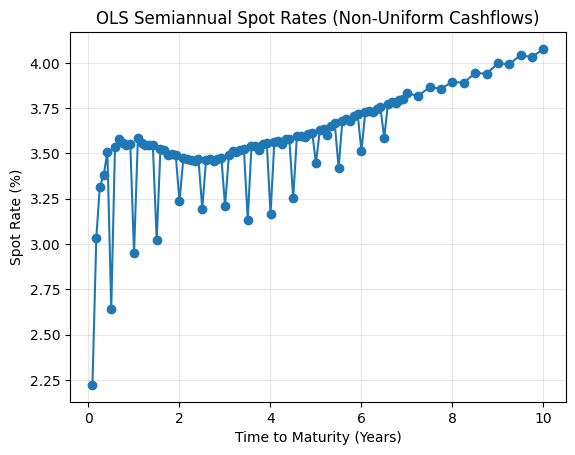

In [36]:
nominal_df["mat_snap"] = pd.to_datetime(nominal_df["mat_snap"])

# Dates where at least one bond matures
maturity_dates = nominal_df["mat_snap"].unique()

# Keep only those columns
C_hat = C.loc[:, C.columns.isin(maturity_dates)].copy()

valid_issues = nominal_df["KYTREASNO"][
    nominal_df["mat_snap"].isin(C_hat.columns)
]

C_hat = C_hat.loc[valid_issues].copy()
display(C_hat.head())
display(C_hat.tail())

p_hat = (
    nominal_df
      .set_index("KYTREASNO")
      .loc[C_hat.index, "dirty price"]
      .to_numpy(dtype=float)
)

#OLS without Constant:
C_hat_mat = C_hat.to_numpy(dtype=float)
z_ols, residuals, rank, svals = np.linalg.lstsq(C_hat_mat, p_hat, rcond=None)
z_ols = pd.Series(z_ols, index=pd.to_datetime(C_hat.columns).normalize(), name="discount_factor_ols")

#Convert to spot rates (semiannual compounding)
quote_date = pd.to_datetime(nominal_df["quote date"].iloc[0]).normalize()

ttm = (
    (z_ols.index - quote_date).days / 365.25
)

r_ols_sa = discount_to_spot_freq(
    z_ols.to_numpy(dtype=float),
    ttm=ttm.to_numpy(dtype=float),
    freq=2
)

order = np.argsort(ttm.to_numpy())

plt.figure()
plt.plot(ttm.to_numpy()[order], 100 * r_ols_sa[order], marker="o")
plt.title("OLS Semiannual Spot Rates (Non-Uniform Cashflows)")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Spot Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()


### 2.3. Nelson-Siegel Curve-Fitting

As in `1.4`, estimate the Nelson-Siegel curve.

In [43]:
C_hat_mat = C_hat.to_numpy(dtype=float)
p_hat = np.asarray(p_hat, dtype=float).reshape(-1)

quote_date = pd.to_datetime(quote_date).normalize()
grid_dates = pd.to_datetime(C_hat.columns).normalize()

t = ((grid_dates - quote_date).days.to_numpy(dtype=float) / 365.25)

# Nelson–Siegel functions (theta/lambda notation)
def ns_yield_cc(t, theta0, theta1, theta2, lambda_1):
    """Nelson–Siegel continuously-compounded spot rate y(t)."""
    t = np.asarray(t, dtype=float)
    x = t / lambda_1

    # handle t ~ 0 safely
    f1 = np.where(t == 0, 1.0, (1.0 - np.exp(-x)) / x)
    f2 = f1 - np.exp(-x)

    return theta0 + theta1 * f1 + theta2 * f2

def ns_discount(t, theta0, theta1, theta2, lambda_1):
    """Discount factor z(t) = exp(-y(t)*t)."""
    y = ns_yield_cc(t, theta0, theta1, theta2, lambda_1)
    return np.exp(-y * t)

def ns_objective(params, C, p_mkt, t):
    """Sum of squared pricing errors."""
    theta0, theta1, theta2, lambda_1 = params
    if lambda_1 <= 0:
        return 1e12
    z = ns_discount(t, theta0, theta1, theta2, lambda_1)
    p_model = C @ z
    err = p_model - p_mkt
    return float(np.sum(err**2))

# Fit (minimize price SSE)
x0 = np.array([0.04, -0.02, 0.02, 2.0])  # starting guess: (theta0, theta1, theta2, lambda_1)
bounds = [(-0.05, 0.20), (-0.50, 0.50), (-0.50, 0.50), (0.05, 30.0)]

res_ns = minimize(
    ns_objective,
    x0,
    args=(C_hat_mat, p_hat, t),
    method="L-BFGS-B",
    bounds=bounds
)

theta0_hat, theta1_hat, theta2_hat, lambda_1_hat = res_ns.x

ns_results2 = pd.DataFrame(
    {
        "Nelson-Siegel": [
            theta0_hat,
            theta1_hat,
            theta2_hat,
            lambda_1_hat,
            res_ns.fun
        ]
    },
    index=[
        "theta 0",
        "theta 1",
        "theta 2",
        "lambda_1",
        "Price SSE"
    ]
)

display(ns_results2.T)

# Compute NS semiannual spot rates
z_ns = ns_discount(t, theta0_hat, theta1_hat, theta2_hat, lambda_1_hat)
r_ns_sa = discount_to_spot_freq(z_ns, ttm=t, freq=2)


,theta 0,theta 1,theta 2,lambda_1,Price SSE
Nelson-Siegel,0.057367,-0.022406,-0.033627,3.676426,63.422165


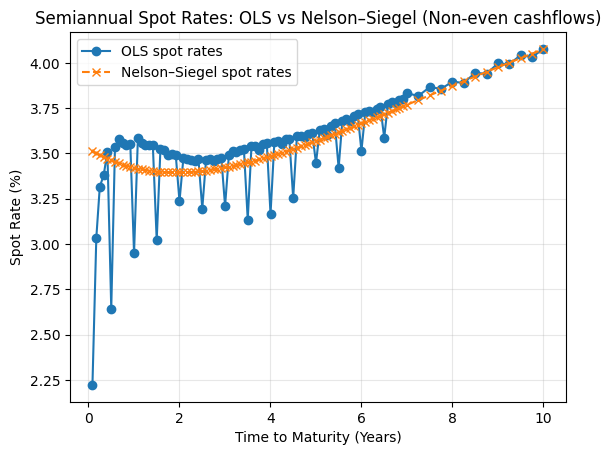

In [ ]:
#Plot OLS vs NS:

order = np.argsort(t)

plt.figure()
plt.plot(t[order], 100 * r_ols_sa[order], marker="o", linestyle="-", label="OLS spot rates")
plt.plot(t[order], 100 * r_ns_sa[order], marker="x", linestyle="--", label="Nelson–Siegel spot rates")
plt.title("Semiannual Spot Rates: OLS vs Nelson–Siegel (Non-even cashflows)")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Spot Rate (%)")
plt.legend()
plt.show()


### 2.4. Weighted Least Squares

Re-do `2.2.`, but this time use Weighted Least Squares. Find a weighting scheme that puts more weight on more recently issued treasures and less weight on less recently issued treasures. 

Does your answer change much?


In [45]:
df_aligned = nominal_df.set_index("KYTREASNO").loc[C_hat.index].copy()

p = df_aligned["dirty price"].to_numpy(dtype=float).reshape(-1)

issue_dates = pd.to_datetime(
    nominal_df.set_index("KYTREASNO").loc[C_hat.index, "issue date"]
).dt.normalize()

quote_date = pd.to_datetime(df_aligned["quote date"].iloc[0]).normalize()
mat_snap = pd.to_datetime(df_aligned["mat_snap"]).dt.normalize()

#Maturity Filter
ttm_issue = (mat_snap - quote_date).dt.days / 365.25
keep = (ttm_issue >= 0.5) & (ttm_issue <= 10.0)

C_use = C_hat.loc[keep].copy()
p_use = p[keep.to_numpy()]
issue_use = issue_dates.loc[keep]

# Recency Weights (more weight on recent issuance)
age_years = (quote_date - issue_use).dt.days.to_numpy(dtype=float) / 365.25

half_life = 2.0  # years; smaller = stronger emphasis on recent issues
w = 2.0 ** (-age_years / half_life)
w = w / np.mean(w)   # normalize (optional but nice)

# OLS estimate (baseline, no constant)
C_mat = C_use.to_numpy(dtype=float)

z_ols, *_ = np.linalg.lstsq(C_mat, p_use, rcond=None)
z_ols = pd.Series(z_ols, index=C_use.columns, name="discount_factor_ols")

# WLS estimate via weighted least squares transform
sqrt_w = np.sqrt(w)
C_tilde = C_mat * sqrt_w[:, None]
p_tilde = p_use * sqrt_w

z_wls, *_ = np.linalg.lstsq(C_tilde, p_tilde, rcond=None)
z_wls = pd.Series(z_wls, index=C_use.columns, name="discount_factor_wls")

# Convert to semiannual spot rates
grid_dates = pd.to_datetime(C_use.columns).normalize()
t = (grid_dates - quote_date).days.to_numpy(dtype=float) / 365.25

r_ols_sa = discount_to_spot_freq(z_ols.to_numpy(dtype=float), ttm=t, freq=2)
r_wls_sa = discount_to_spot_freq(z_wls.to_numpy(dtype=float), ttm=t, freq=2)

#Convert to semiannual spot rates
grid_dates = pd.to_datetime(C_use.columns).normalize()
t = (grid_dates - quote_date).days.to_numpy(dtype=float) / 365.25

r_ols_sa = discount_to_spot_freq(z_ols.to_numpy(dtype=float), ttm=t, freq=2)
r_wls_sa = discount_to_spot_freq(z_wls.to_numpy(dtype=float), ttm=t, freq=2)

#Quantify OLS vs WLS differences
diff_bp = 10000 * (r_wls_sa - r_ols_sa)

print("Bonds used:", C_use.shape[0])
print("Curve dates:", C_use.shape[1])
print("Mean |WLS − OLS| (bp):", float(np.nanmean(np.abs(diff_bp))))
print("Max  |WLS − OLS| (bp):", float(np.nanmax(np.abs(diff_bp))))


Bonds used: 232
Curve dates: 96
Mean |WLS − OLS| (bp): 120.7166732596747
Max  |WLS − OLS| (bp): 5341.075131694124


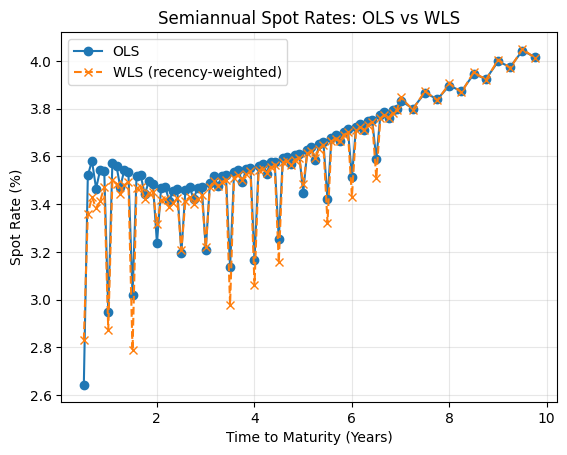

In [46]:
#OLS vs WLS Plot

#Drop near-zero maturities
mask = t >= 0.5   # 6 months

t_plot = t[mask]
r_ols_plot = r_ols_sa[mask]
r_wls_plot = r_wls_sa[mask]

order = np.argsort(t_plot)

plt.figure()
plt.plot(t_plot[order], 100 * r_ols_plot[order],
         marker="o", linestyle="-", label="OLS")
plt.plot(t_plot[order], 100 * r_wls_plot[order],
         marker="x", linestyle="--", label="WLS (recency-weighted)")
plt.title("Semiannual Spot Rates: OLS vs WLS")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Spot Rate (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Yes, the OLS and WLS answers are different.

***